# Feature Engineering Improvements — V2 Benchmark

Measures the impact of three targeted improvements over the baseline enriched pipeline:

| # | Improvement | Change | Rationale |
|---|-------------|--------|-----------|
| 1 | **Cyclic time encoding** | Replace 14 month/quarter dummies with 4 sin/cos features | Correct seasonal adjacency; Dec ↔ Jan are close, not opposite |
| 2 | **Current-month holidays** | Remove t-1 lag from holiday features | Holidays are known calendar facts — no leakage at time t |
| 3 | **Country-level hierarchy** | Add leave-one-out country aggregate (t-1) | National conflict context; approximates a hierarchical prior |

**Evaluation**: 5 models × 6 feature sets × 3 targets × top-10 regions = 900 evaluations, 6-month holdout.

**Comparison**: V1 ablation results (already on disk) vs V2 ablation results (run below).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')  # run from forecast_model/ so relative data paths work

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from utils.preprocessing_v2 import prepare_enriched_pipeline_v2, build_feature_sets_v2
from utils.ablation import MODELS
from utils.evaluators import find_top_regions, evaluate_model
from config import settings

print('Imports OK')

Imports OK


## 1. Build V2 Dataset

Rebuilds from raw data with all three improvements applied.
Cached to `data/processed/model_data_v2_enriched.csv` — pass `clean_data=True` to force rebuild.

In [2]:
df_v2 = prepare_enriched_pipeline_v2(clean_data=False)

print(f'\nV2 dataset: {df_v2.shape[0]:,} rows × {df_v2.shape[1]} columns')

# Verify new features are present
checks = {
    'Cyclic months':    ['month_sin', 'month_cos', 'quarter_sin', 'quarter_cos'],
    'No-lag holidays':  ['holiday_count_month', 'is_holiday_month'],
    'Country features': ['country_battles_excl (t-1)', 'country_remote_excl (t-1)',
                         'country_vac_excl (t-1)', 'country_total_excl (t-1)'],
    'Dummies removed':  ['month_2', 'quarter_2'],
    'Lag holidays gone':['n_holidays_lag1', 'is_holiday_month_lag1'],
}

print('\nFeature presence check:')
for label, cols in checks.items():
    present = [c for c in cols if c in df_v2.columns]
    absent  = [c for c in cols if c not in df_v2.columns]
    if label in ('Dummies removed', 'Lag holidays gone'):
        status = 'OK (absent)' if not present else f'WARN — still present: {present}'
    else:
        status = f'OK ({len(present)}/{len(cols)})' if present else f'MISSING: {absent}'
    print(f'  {label:20s}: {status}')

Building v2 enriched dataset...


Matching: 100%|██████████| 3330/3330 [00:00<00:00, 16101.05it/s]


Applying spatial geocoordinate fallback for 8038 unmapped events...


Get neighbour counts: 100%|██████████| 289890/289890 [00:01<00:00, 248222.68it/s]


  [v2] Merging risk indicators...
  [v2] Adding macro indicators...
  [v2] Adding current-month holiday features (no lag)...
  [v2] Adding religion features...
  [v2] Adding country-level hierarchy features...
  [v2] Building engineered features...
  Saved v2 enriched: d:\gconflict\predicting-global-conflict2\forecast_model\data\processed\model_data_v2_enriched.csv

V2 dataset: 289,890 rows × 78 columns

Feature presence check:
  Cyclic months       : OK (4/4)
  No-lag holidays     : OK (2/2)
  Country features    : OK (4/4)
  Dummies removed     : OK (absent)
  Lag holidays gone   : OK (absent)


## 2. Run V2 Ablation (900 evaluations)

6 feature sets × 5 models × 3 targets × 10 regions. The extra tier vs V1 is **+Country**.

In [3]:
feature_sets_v2 = build_feature_sets_v2(df_v2)
top_regions     = find_top_regions(df_v2, settings.targets, n=10)

print('V2 feature sets:')
for name, cols in feature_sets_v2.items():
    print(f'  {name:12s}: {len(cols)} features')

print(f'\nTop-10 regions: {top_regions}')

V2 feature sets:
  Baseline    : 20 features
  +Risk       : 27 features
  +Macro      : 31 features
  +Holidays   : 33 features
  +Country    : 37 features
  +Engineered : 46 features

Top-10 regions: ['UKR - Donetsk', 'UKR - Kharkiv', 'UKR - Sumy', 'SYR - Idlib', 'PSX - Gaza', 'UKR - Kherson', 'BRA - Rio de Janeiro', 'SYR - Aleppo', 'UKR - Zaporizhzhia', 'UKR - Luhansk']


In [4]:
combos = list(iproduct(MODELS.keys(), feature_sets_v2.keys(), settings.targets, top_regions))
print(f'Running {len(combos)} V2 evaluations '
      f'({len(MODELS)} models × {len(feature_sets_v2)} feature sets × '
      f'{len(settings.targets)} targets × {len(top_regions)} regions)...')

records_v2 = []
for i, (model_name, fs_name, target, region) in enumerate(combos):
    result = evaluate_model(
        df_v2, region, target,
        feature_sets_v2[fs_name],
        MODELS[model_name],
        holdout=6,
    )
    if result is not None:
        records_v2.append({'model': model_name, 'feature_set': fs_name,
                           'target': target, 'region': region, **result})
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(combos)} done...')

ablation_v2 = pd.DataFrame(records_v2)
os.makedirs('outputs', exist_ok=True)
ablation_v2.to_csv('outputs/ablation_results_v2.csv', index=False)
print(f'Done. {len(records_v2)} results. Saved to outputs/ablation_results_v2.csv')

Running 900 V2 evaluations (5 models × 6 feature sets × 3 targets × 10 regions)...
  100/900 done...
  200/900 done...
  300/900 done...
  400/900 done...
  500/900 done...
  600/900 done...
  700/900 done...
  800/900 done...
  900/900 done...
Done. 900 results. Saved to outputs/ablation_results_v2.csv


## 3. V2 Ablation Results

In [5]:
fs_names_v2 = list(feature_sets_v2.keys())

print('=' * 80)
print('V2 MEAN MAE — ALL REGIONS + TARGETS COMBINED')
print('=' * 80)
pivot_v2_all = (
    ablation_v2.groupby(['model', 'feature_set'])['mae']
    .mean().unstack('feature_set')[fs_names_v2].round(2)
)
print(pivot_v2_all.to_string())

print('\n' + '=' * 80)
print('V2 PER-TARGET BREAKDOWN')
print('=' * 80)
for target in settings.targets:
    sub = ablation_v2[ablation_v2['target'] == target]
    pivot_t = (
        sub.groupby(['model', 'feature_set'])['mae']
        .mean().unstack('feature_set').reindex(columns=fs_names_v2).round(2)
    )
    print(f'\nTarget: {target}')
    print(pivot_t.to_string())

V2 MEAN MAE — ALL REGIONS + TARGETS COMBINED
feature_set   Baseline  +Risk  +Macro  +Holidays  +Country  +Engineered
model                                                                  
GBR              64.25  65.17   67.00      65.90     69.47        63.73
LGBM-Poisson     55.64  55.84   55.78      55.85     56.83        56.71
LGBM-Tweedie     56.84  56.94   57.62      57.59     53.05        53.60
RF               58.98  59.10   60.48      59.43     60.11        60.08
XGBoost          63.84  63.22   63.17      63.40     64.10        60.56

V2 PER-TARGET BREAKDOWN

Target: Battles
feature_set   Baseline  +Risk  +Macro  +Holidays  +Country  +Engineered
model                                                                  
GBR              65.52  67.15   66.08      65.64     71.24        56.34
LGBM-Poisson     48.56  48.82   48.74      48.83     49.73        50.67
LGBM-Tweedie     49.84  50.14   50.27      50.39     47.50        50.94
RF               58.08  57.47   60.04      58.53 

## 4. V1 vs V2 — Head-to-Head Comparison

Compares the **best feature set** from each pipeline across all models and targets.
V1 best = `+Engineered` (5 tiers). V2 best = `+Engineered` (6 tiers, includes +Country).

In [6]:
ablation_v1 = pd.read_csv('outputs/ablation_results.csv')

# Extract best feature set from each pipeline
v1_best = ablation_v1[ablation_v1['feature_set'] == '+Engineered'].copy()
v2_best = ablation_v2[ablation_v2['feature_set'] == '+Engineered'].copy()

v1_mean = v1_best.groupby('model')['mae'].mean().rename('V1 +Engineered')
v2_mean = v2_best.groupby('model')['mae'].mean().rename('V2 +Engineered')

comparison = pd.concat([v1_mean, v2_mean], axis=1).round(2)
comparison['Delta (V2 - V1)'] = (comparison['V2 +Engineered'] - comparison['V1 +Engineered']).round(2)
comparison['% Change'] = ((comparison['Delta (V2 - V1)'] / comparison['V1 +Engineered']) * 100).round(1)

print('Head-to-head: V1 +Engineered vs V2 +Engineered (mean MAE, all targets + regions)')
print(comparison.to_string())
print('\nNegative Delta = V2 is better (lower MAE)')

Head-to-head: V1 +Engineered vs V2 +Engineered (mean MAE, all targets + regions)
              V1 +Engineered  V2 +Engineered  Delta (V2 - V1)  % Change
model                                                                  
GBR                    61.42           63.73             2.31       3.8
LGBM-Poisson           53.20           56.71             3.51       6.6
LGBM-Tweedie           57.73           53.60            -4.13      -7.2
RF                     57.37           60.08             2.71       4.7
XGBoost                60.41           60.56             0.15       0.2

Negative Delta = V2 is better (lower MAE)


In [7]:
print('Per-target comparison (V1 vs V2 +Engineered, RF and LGBM-Poisson):')
print()

for target in settings.targets:
    v1_t = v1_best[v1_best['target'] == target].groupby('model')['mae'].mean()
    v2_t = v2_best[v2_best['target'] == target].groupby('model')['mae'].mean()
    tbl = pd.concat([v1_t.rename('V1'), v2_t.rename('V2')], axis=1).round(2)
    tbl['Δ']  = (tbl['V2'] - tbl['V1']).round(2)
    tbl['%']  = ((tbl['Δ'] / tbl['V1']) * 100).round(1)
    print(f'--- {target} ---')
    print(tbl.to_string())
    print()

Per-target comparison (V1 vs V2 +Engineered, RF and LGBM-Poisson):

--- Battles ---
                 V1     V2     Δ    %
model                                
GBR           57.13  56.34 -0.79 -1.4
LGBM-Poisson  51.28  50.67 -0.61 -1.2
LGBM-Tweedie  50.52  50.94  0.42  0.8
RF            54.34  57.33  2.99  5.5
XGBoost       49.62  51.11  1.49  3.0

--- Explosions/Remote violence ---
                  V1      V2      Δ     %
model                                    
GBR           121.76  129.36   7.60   6.2
LGBM-Poisson  103.44  114.54  11.10  10.7
LGBM-Tweedie  117.80  105.05 -12.75 -10.8
RF            112.74  117.82   5.08   4.5
XGBoost       126.24  125.60  -0.64  -0.5

--- Violence against civilians ---
                V1    V2     Δ    %
model                              
GBR           5.37  5.48  0.11  2.0
LGBM-Poisson  4.89  4.91  0.02  0.4
LGBM-Tweedie  4.88  4.82 -0.06 -1.2
RF            5.03  5.08  0.05  1.0
XGBoost       5.37  4.97 -0.40 -7.4



## 5. Per-Improvement Breakdown (V2 incremental gains)

Each improvement's marginal contribution is visible in the step-by-step feature set addition.
V1 reference: `Baseline → +Risk → +Macro → +Holidays → +Engineered` (RF only, for clarity).

In [8]:
rf_v1 = ablation_v1[ablation_v1['model'] == 'RF']
rf_v2 = ablation_v2[ablation_v2['model'] == 'RF']

v1_steps = ['Baseline', '+Risk', '+Macro', '+Holidays', '+Engineered']
v2_steps = ['Baseline', '+Risk', '+Macro', '+Holidays', '+Country', '+Engineered']

v1_rf_means = rf_v1.groupby('feature_set')['mae'].mean().reindex(v1_steps).round(2)
v2_rf_means = rf_v2.groupby('feature_set')['mae'].mean().reindex(v2_steps).round(2)

print('RF MAE at each feature tier (mean over all targets + regions):')
print()
print(f"{'Feature set':15s}  {'V1 MAE':>8s}  {'V2 MAE':>8s}  {'V2 Δ vs prev':>14s}")
print('-' * 55)

prev = None
for fs in v2_steps:
    v1_val = v1_rf_means.get(fs, float('nan'))
    v2_val = v2_rf_means.get(fs, float('nan'))
    delta_str = ''
    if prev is not None and not np.isnan(v2_val) and not np.isnan(prev):
        delta = v2_val - prev
        delta_str = f'{delta:+.2f} ({delta/prev*100:+.1f}%)'
    v1_str = f'{v1_val:.2f}' if not np.isnan(v1_val) else '  —  '
    print(f'{fs:15s}  {v1_str:>8s}  {v2_val:>8.2f}  {delta_str:>14s}')
    prev = v2_val

RF MAE at each feature tier (mean over all targets + regions):

Feature set        V1 MAE    V2 MAE    V2 Δ vs prev
-------------------------------------------------------
Baseline            57.25     58.98                
+Risk               57.95     59.10   +0.12 (+0.2%)
+Macro              56.64     60.48   +1.38 (+2.3%)
+Holidays           57.12     59.43   -1.05 (-1.7%)
+Country              —       60.11   +0.68 (+1.1%)
+Engineered         57.37     60.08   -0.03 (-0.0%)


## 6. Visualization — V1 vs V2 MAE Heatmaps

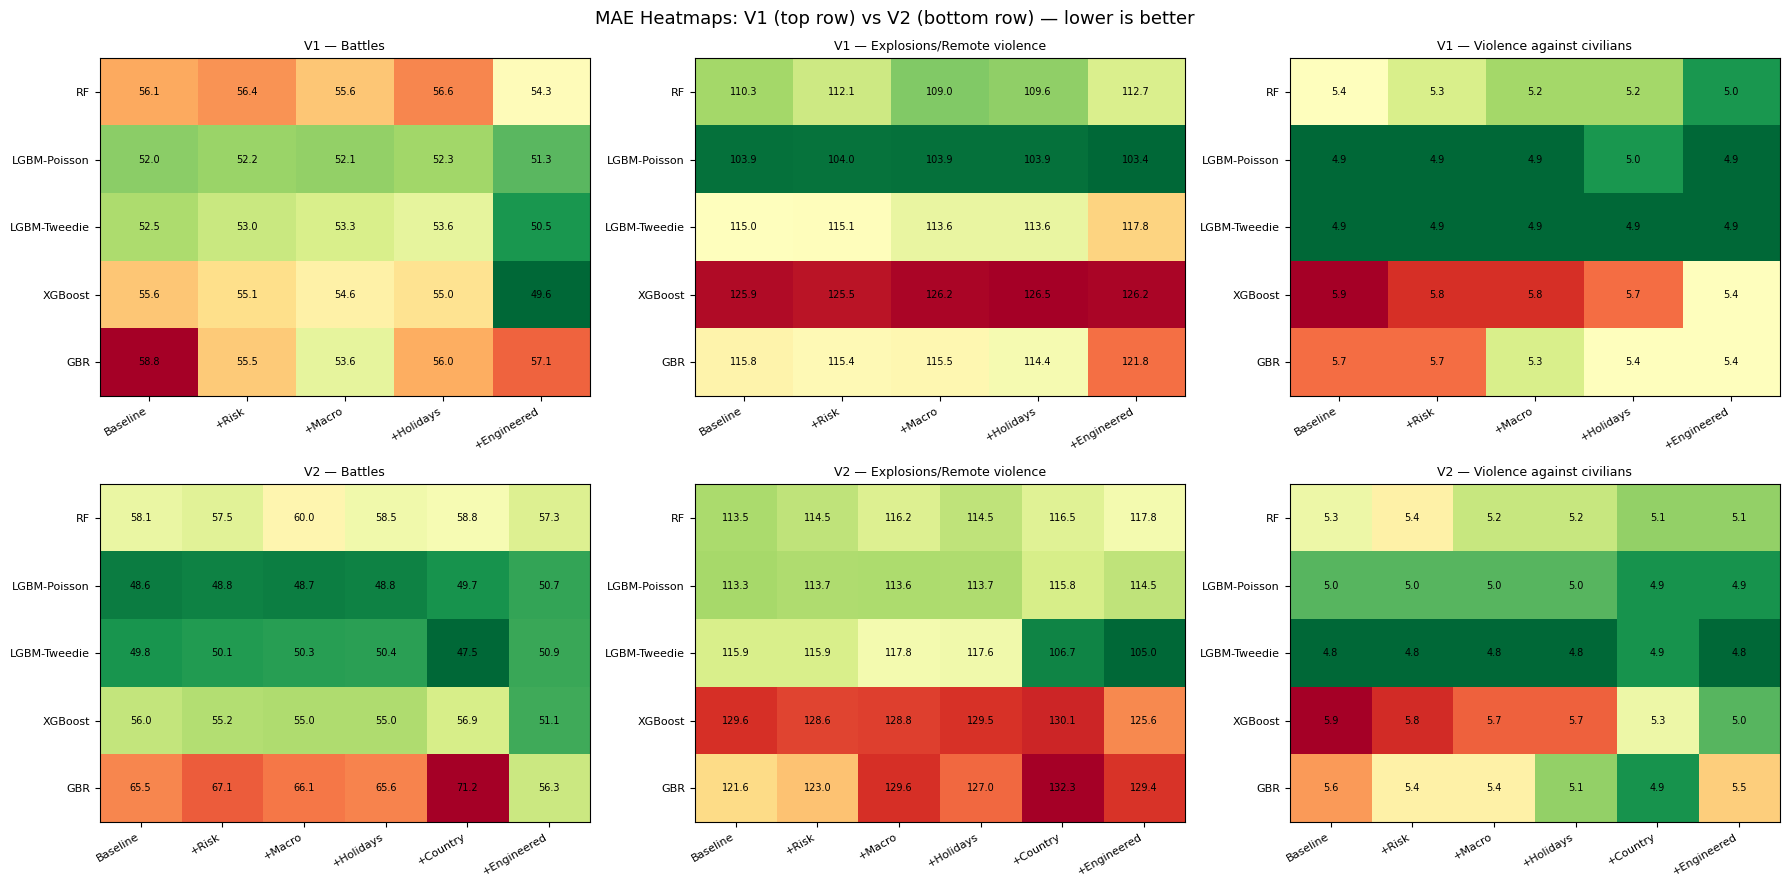

Saved: outputs/figures/v1_vs_v2_heatmaps.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('MAE Heatmaps: V1 (top row) vs V2 (bottom row) — lower is better', fontsize=13)

model_order = ['RF', 'LGBM-Poisson', 'LGBM-Tweedie', 'XGBoost', 'GBR']

for col_idx, target in enumerate(settings.targets):
    # V1
    sub_v1 = ablation_v1[ablation_v1['target'] == target]
    piv_v1 = (
        sub_v1.groupby(['model', 'feature_set'])['mae'].mean()
        .unstack('feature_set')[['Baseline', '+Risk', '+Macro', '+Holidays', '+Engineered']]
        .reindex(model_order).round(1)
    )
    ax = axes[0, col_idx]
    im = ax.imshow(piv_v1.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(piv_v1.columns)))
    ax.set_xticklabels(piv_v1.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(piv_v1.index)))
    ax.set_yticklabels(piv_v1.index, fontsize=8)
    ax.set_title(f'V1 — {target}', fontsize=9)
    for r in range(piv_v1.shape[0]):
        for c in range(piv_v1.shape[1]):
            ax.text(c, r, f'{piv_v1.values[r, c]:.1f}', ha='center', va='center', fontsize=7)

    # V2
    sub_v2 = ablation_v2[ablation_v2['target'] == target]
    piv_v2 = (
        sub_v2.groupby(['model', 'feature_set'])['mae'].mean()
        .unstack('feature_set')[fs_names_v2]
        .reindex(model_order).round(1)
    )
    ax = axes[1, col_idx]
    ax.imshow(piv_v2.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(piv_v2.columns)))
    ax.set_xticklabels(piv_v2.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(piv_v2.index)))
    ax.set_yticklabels(piv_v2.index, fontsize=8)
    ax.set_title(f'V2 — {target}', fontsize=9)
    for r in range(piv_v2.shape[0]):
        for c in range(piv_v2.shape[1]):
            ax.text(c, r, f'{piv_v2.values[r, c]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/v1_vs_v2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/v1_vs_v2_heatmaps.png')

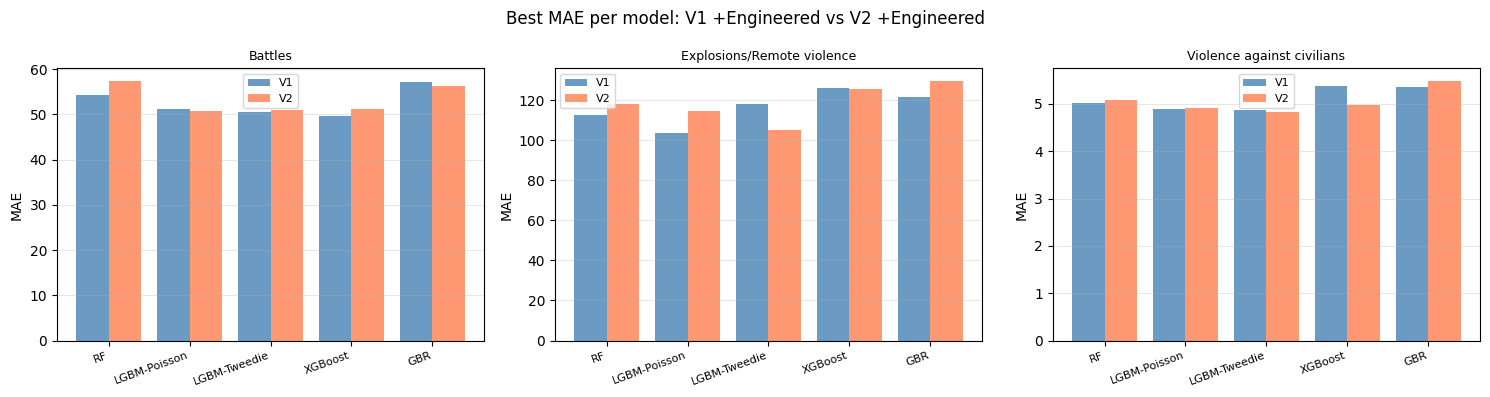

Saved: outputs/figures/v1_vs_v2_bar.png


In [10]:
# Bar chart: V1 vs V2 best-combo MAE per target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Best MAE per model: V1 +Engineered vs V2 +Engineered', fontsize=12)

for ax, target in zip(axes, settings.targets):
    v1_t = (ablation_v1[(ablation_v1['feature_set'] == '+Engineered') &
                         (ablation_v1['target'] == target)]
            .groupby('model')['mae'].mean().reindex(model_order))
    v2_t = (ablation_v2[(ablation_v2['feature_set'] == '+Engineered') &
                         (ablation_v2['target'] == target)]
            .groupby('model')['mae'].mean().reindex(model_order))

    x = np.arange(len(model_order))
    ax.bar(x - 0.2, v1_t.values, width=0.4, label='V1', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, v2_t.values, width=0.4, label='V2', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=20, ha='right', fontsize=8)
    ax.set_title(target, fontsize=9)
    ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/v1_vs_v2_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/v1_vs_v2_bar.png')

## 7. Summary

Key numbers printed below for quick reference.

In [11]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)

# Overall best for each pipeline
for label, abl in [('V1', ablation_v1), ('V2', ablation_v2)]:
    best_row = abl.groupby(['model', 'feature_set'])['mae'].mean().idxmin()
    best_val = abl.groupby(['model', 'feature_set'])['mae'].mean().min()
    rf_base  = abl[(abl['model'] == 'RF') & (abl['feature_set'] == 'Baseline')]['mae'].mean()
    pct      = (best_val - rf_base) / rf_base * 100
    print(f'{label} best: model={best_row[0]}, feature_set={best_row[1]}')
    print(f'     MAE={best_val:.2f}  (RF Baseline: {rf_base:.2f},  {pct:+.1f}%)')

print()
print('V1 vs V2 overall improvement (best combo each):')
v1_best_val = ablation_v1.groupby(['model', 'feature_set'])['mae'].mean().min()
v2_best_val = ablation_v2.groupby(['model', 'feature_set'])['mae'].mean().min()
delta_pct   = (v2_best_val - v1_best_val) / v1_best_val * 100
print(f'  V1 best MAE: {v1_best_val:.2f}')
print(f'  V2 best MAE: {v2_best_val:.2f}')
print(f'  Change:      {delta_pct:+.1f}%  ({'improvement' if delta_pct < 0 else 'regression'})')

print()
print('Country hierarchy marginal impact (RF, mean over all targets + regions):')
rf_holidays = ablation_v2[(ablation_v2['model'] == 'RF') & (ablation_v2['feature_set'] == '+Holidays')]['mae'].mean()
rf_country  = ablation_v2[(ablation_v2['model'] == 'RF') & (ablation_v2['feature_set'] == '+Country')]['mae'].mean()
print(f'  +Holidays → +Country: {rf_country - rf_holidays:+.2f} MAE  ({(rf_country - rf_holidays)/rf_holidays*100:+.1f}%)')

SUMMARY
V1 best: model=LGBM-Poisson, feature_set=+Engineered
     MAE=53.20  (RF Baseline: 57.25,  -7.1%)
V2 best: model=LGBM-Tweedie, feature_set=+Country
     MAE=53.05  (RF Baseline: 58.98,  -10.1%)

V1 vs V2 overall improvement (best combo each):
  V1 best MAE: 53.20
  V2 best MAE: 53.05
  Change:      -0.3%  (improvement)

Country hierarchy marginal impact (RF, mean over all targets + regions):
  +Holidays → +Country: +0.68 MAE  (+1.1%)
